# YOLOv3 детекция шахматных фигур

Модель создаётся **с нуля** — pretrained-веса YOLO не загружаются.

Список классов автоматически читается из `data.yaml`, поэтому число классов не задаётся вручную.

## Установка

In [2]:
%pip install -q "huggingface_hub>=1.23.0,<2.0" pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 12.9 MB/s eta 0:00:00


## Импорты

In [3]:
#===
# Импорты

import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import yaml

from huggingface_hub import snapshot_download
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Add,
    BatchNormalization,
    Concatenate,
    Conv2D,
    Input,
    Layer,
    LeakyReLU,
    UpSampling2D,
    ZeroPadding2D,
)
from tensorflow.keras.regularizers import l2


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


print(
    "TensorFlow:",
    tf.__version__,
)

print(
    "GPU:",
    tf.config.list_physical_devices(
        "GPU"
    ),
)

TensorFlow: 2.20.0
GPU: []


## Датасет

Используем публичный набор шахматных фигур в YOLO-формате.

Структура:

```text
chess_yolo/
├── data.yaml
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
└── test/
    ├── images/
    └── labels/
```

Разметка каждой фигуры:

```text
class_id x_center y_center width height
```

Координаты нормированы от 0 до 1.

In [4]:
#===
# Загрузка датасета

DATA_DIR = Path(
    "/content/chess_yolo"
)


# На карточке датасета встречаются два варианта
# написания namespace, поэтому оставляем fallback.
repo_ids = [
    "LibreYOLO/chess-pieces-mjzgj",
    "Libre-YOLO/chess-pieces-mjzgj",
]


downloaded = False


for repo_id in repo_ids:

    try:
        snapshot_download(
            repo_id=repo_id,
            repo_type="dataset",
            local_dir=str(
                DATA_DIR
            ),
        )

        print(
            "Загружено из:",
            repo_id,
        )

        downloaded = True
        break

    except Exception as error:
        print(
            "Не удалось:",
            repo_id,
            "|",
            type(error).__name__,
        )


if not downloaded:
    raise RuntimeError(
        "Не удалось загрузить датасет шахматных фигур"
    )


print(
    "Датасет:",
    DATA_DIR
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 583 files:   0%|          | 0/583 [00:00<?, ?it/s]

Загружено из: LibreYOLO/chess-pieces-mjzgj
Датасет: /content/chess_yolo


In [5]:
#===
# Классы

yaml_path = (
    DATA_DIR
    / "data.yaml"
)


with open(
    yaml_path,
    "r",
    encoding="utf-8",
) as file:
    data_config = yaml.safe_load(
        file
    )


names = data_config[
    "names"
]


if isinstance(
    names,
    dict,
):
    CLASS_NAMES = [
        names[key]
        for key
        in sorted(
            names,
            key=lambda x: int(x),
        )
    ]
else:
    CLASS_NAMES = list(
        names
    )


NUM_CLASSES = len(
    CLASS_NAMES
)


print(
    "Число классов:",
    NUM_CLASSES
)

for class_id, name in enumerate(
    CLASS_NAMES
):
    print(
        class_id,
        "->",
        name,
    )

Число классов: 13
0 -> bishop
1 -> black-bishop
2 -> black-king
3 -> black-knight
4 -> black-pawn
5 -> black-queen
6 -> black-rook
7 -> white-bishop
8 -> white-king
9 -> white-knight
10 -> white-pawn
11 -> white-queen
12 -> white-rook


## Параметры YOLOv3

In [6]:
#===
# Параметры

SIZE = 416

BATCH_SIZE = 2

EPOCHS = 20

MAX_BOXES = 50


# Стандартные anchors YOLOv3.
# Делим на 416, чтобы координаты
# были нормированы от 0 до 1.
YOLO_ANCHORS = (
    np.array(
        [
            (10, 13),
            (16, 30),
            (33, 23),
            (30, 61),
            (62, 45),
            (59, 119),
            (116, 90),
            (156, 198),
            (373, 326),
        ],
        dtype=np.float32,
    )
    / 416.0
)


# Крупные, средние и малые anchors.
YOLO_ANCHOR_MASKS = np.array(
    [
        [6, 7, 8],
        [3, 4, 5],
        [0, 1, 2],
    ],
    dtype=np.int32,
)


print(
    "Anchors:",
    YOLO_ANCHORS.shape,
)

Anchors: (9, 2)


## Чтение YOLO-разметки

Разметку вида:

```text
class x_center y_center width height
```

преобразуем в:

```text
x1 y1 x2 y2 class
```

Именно такой формат дальше используется функциями подготовки targets.

In [7]:
#===
# YOLO label -> box

def read_yolo_label(
    label_path,
    max_boxes=MAX_BOXES,
):
    boxes = np.zeros(
        (
            max_boxes,
            5,
        ),
        dtype=np.float32,
    )


    label_path = Path(
        label_path
    )


    if not label_path.exists():
        return boxes


    lines = (
        label_path
        .read_text(
            encoding="utf-8"
        )
        .strip()
        .splitlines()
    )


    box_index = 0


    for line in lines:

        if not line.strip():
            continue


        values = (
            line
            .strip()
            .split()
        )


        if len(values) != 5:
            continue


        class_id = int(
            float(
                values[0]
            )
        )

        x_center = float(
            values[1]
        )

        y_center = float(
            values[2]
        )

        width = float(
            values[3]
        )

        height = float(
            values[4]
        )


        x1 = (
            x_center
            - width / 2
        )

        y1 = (
            y_center
            - height / 2
        )

        x2 = (
            x_center
            + width / 2
        )

        y2 = (
            y_center
            + height / 2
        )


        boxes[
            box_index
        ] = [
            np.clip(
                x1,
                0,
                1,
            ),

            np.clip(
                y1,
                0,
                1,
            ),

            np.clip(
                x2,
                0,
                1,
            ),

            np.clip(
                y2,
                0,
                1,
            ),

            class_id,
        ]


        box_index += 1


        if box_index >= max_boxes:
            break


    return boxes

In [8]:
#===
# Пути изображений и labels

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
}


def load_split(
    split_name,
):
    image_dir = (
        DATA_DIR
        / split_name
        / "images"
    )

    label_dir = (
        DATA_DIR
        / split_name
        / "labels"
    )


    image_paths = sorted(
        [
            path
            for path
            in image_dir.iterdir()
            if path.suffix.lower()
            in IMAGE_EXTENSIONS
        ]
    )


    labels = []


    for image_path in image_paths:

        label_path = (
            label_dir
            / (
                image_path.stem
                + ".txt"
            )
        )

        labels.append(
            read_yolo_label(
                label_path
            )
        )


    return (
        [
            str(path)
            for path
            in image_paths
        ],
        np.asarray(
            labels,
            dtype=np.float32,
        ),
    )


train_paths, train_boxes = (
    load_split(
        "train"
    )
)

valid_paths, valid_boxes = (
    load_split(
        "valid"
    )
)

test_paths, test_boxes = (
    load_split(
        "test"
    )
)


print(
    "TRAIN:",
    len(
        train_paths
    )
)

print(
    "VALID:",
    len(
        valid_paths
    )
)

print(
    "TEST:",
    len(
        test_paths
    )
)

TRAIN: 202
VALID: 58
TEST: 29


## Проверка исходной разметки

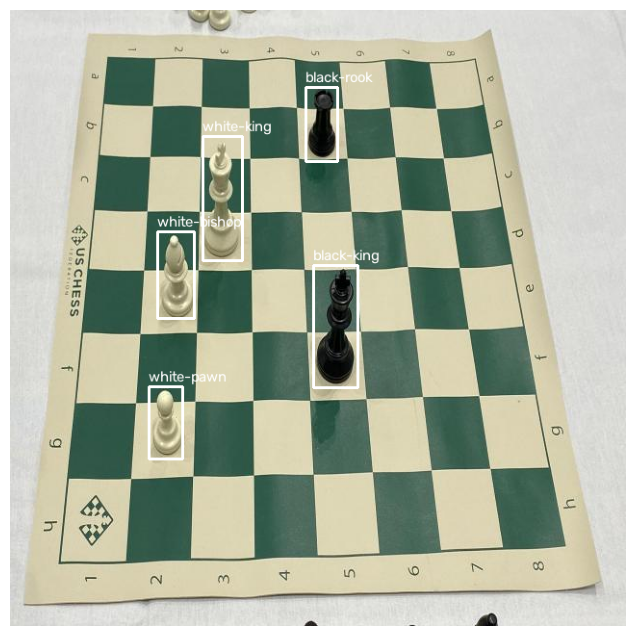

In [9]:
#===
# Рисуем истинные рамки

def draw_true_boxes(
    image_path,
    boxes,
):
    image = cv2.imread(
        image_path
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB,
    )


    height, width = (
        image.shape[:2]
    )


    for box in boxes:

        x1, y1, x2, y2, class_id = (
            box
        )


        if x2 <= 0:
            continue


        x1 = int(
            x1 * width
        )

        y1 = int(
            y1 * height
        )

        x2 = int(
            x2 * width
        )

        y2 = int(
            y2 * height
        )


        class_id = int(
            class_id
        )


        cv2.rectangle(
            image,
            (
                x1,
                y1,
            ),
            (
                x2,
                y2,
            ),
            (
                255,
                255,
                255,
            ),
            2,
        )


        cv2.putText(
            image,
            CLASS_NAMES[
                class_id
            ],
            (
                x1,
                max(
                    20,
                    y1 - 5,
                ),
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (
                255,
                255,
                255,
            ),
            1,
            cv2.LINE_AA,
        )


    return image


sample_index = random.randrange(
    len(
        train_paths
    )
)


sample_image = draw_true_boxes(
    train_paths[
        sample_index
    ],
    train_boxes[
        sample_index
    ],
)


plt.figure(
    figsize=(
        8,
        8,
    )
)

plt.imshow(
    sample_image
)

plt.axis(
    "off"
)

plt.show()

## DBL

Базовый блок YOLOv3:

```text
Conv2D -> BatchNormalization -> LeakyReLU
```

При `stride=2` предварительно добавляется padding.

In [10]:
#===
# DarkNet Block Layer

def DBL(
    x,
    filters,
    kernel,
    stride=1,
    batch_norm=True,
):

    if stride == 1:
        padding = "same"

    else:
        x = ZeroPadding2D(
            (
                (
                    1,
                    0,
                ),
                (
                    1,
                    0,
                ),
            )
        )(
            x
        )

        padding = "valid"


    x = Conv2D(
        filters=filters,

        kernel_size=kernel,

        strides=stride,

        padding=padding,

        use_bias=(
            not batch_norm
        ),

        kernel_regularizer=(
            l2(
                0.0005
            )
        ),
    )(
        x
    )


    if batch_norm:

        x = BatchNormalization()(
            x
        )

        x = LeakyReLU(
            negative_slope=0.1
        )(
            x
        )


    return x

## Residual-блоки

In [11]:
#===
# Residual Unit

def ResUnit(
    x,
    filters,
):
    shortcut = x


    x = DBL(
        x,
        filters // 2,
        1,
    )

    x = DBL(
        x,
        filters,
        3,
    )


    x = Add()(
        [
            shortcut,
            x,
        ]
    )


    return x


#===
# Residual Block

def ResBlock(
    x,
    filters,
    blocks,
):

    x = DBL(
        x,
        filters,
        3,
        stride=2,
    )


    for _ in range(
        blocks
    ):
        x = ResUnit(
            x,
            filters,
        )


    return x

## Darknet-53

Backbone извлекает признаки в трёх масштабах:

- `Route_1` — для мелких объектов;
- `Route_2` — для средних;
- `Route_3` — для крупных.

In [12]:
#===
# Darknet-53

def Darknet():

    inputs = Input(
        shape=(
            SIZE,
            SIZE,
            3,
        )
    )


    x = DBL(
        inputs,
        32,
        3,
    )


    x = ResBlock(
        x,
        64,
        1,
    )


    x = ResBlock(
        x,
        128,
        2,
    )


    x = ResBlock(
        x,
        256,
        8,
    )

    route_1 = x


    x = ResBlock(
        x,
        512,
        8,
    )

    route_2 = x


    x = ResBlock(
        x,
        1024,
        4,
    )

    route_3 = x


    return Model(
        inputs,
        (
            route_1,
            route_2,
            route_3,
        ),
        name="yolo_darknet",
    )

## Головы YOLO

In [13]:
#===
# Yolo Head

def YoloHead(
    x,
    filters,
    skip=None,
):

    if skip is not None:

        x = DBL(
            x,
            filters,
            1,
        )

        x = UpSampling2D(
            2
        )(
            x
        )

        x = Concatenate()(
            [
                x,
                skip,
            ]
        )


    x = DBL(
        x,
        filters,
        1,
    )

    x = DBL(
        x,
        filters * 2,
        3,
    )

    x = DBL(
        x,
        filters,
        1,
    )

    x = DBL(
        x,
        filters * 2,
        3,
    )

    x = DBL(
        x,
        filters,
        1,
    )


    return x

In [14]:
#===
# Reshape выхода головы

class YoloOutputReshape(
    Layer
):
    def __init__(
        self,
        anchors,
        classes,
        **kwargs,
    ):
        super().__init__(
            **kwargs
        )

        self.anchors = anchors

        self.classes = classes


    def call(
        self,
        x,
    ):

        shape = tf.shape(
            x
        )


        return tf.reshape(
            x,
            (
                shape[0],
                shape[1],
                shape[2],
                self.anchors,
                self.classes + 5,
            ),
        )

In [15]:
#===
# Yolo Output

def YoloHeadOutput(
    x,
    filters,
    anchors,
    classes,
):

    x = DBL(
        x,
        filters * 2,
        3,
    )


    x = DBL(
        x,
        anchors
        * (
            classes + 5
        ),
        1,
        batch_norm=False,
    )


    x = YoloOutputReshape(
        anchors,
        classes,
    )(
        x
    )


    return x

## Полный YOLOv3

На выходе получаем три тензора для трёх масштабов.

**Pretrained-веса не загружаются.**  
Все веса инициализируются Keras случайно и обучаются на шахматных фигурах.

In [16]:
#===
# YOLOv3 с нуля

def YoloV3(
    classes,
):

    inputs = Input(
        shape=(
            SIZE,
            SIZE,
            3,
        )
    )


    route_1, route_2, route_3 = (
        Darknet()(
            inputs
        )
    )


    # Крупные объекты
    x = YoloHead(
        route_3,
        512,
    )


    output_0 = YoloHeadOutput(
        x,
        512,
        3,
        classes,
    )


    # Средние объекты
    x = YoloHead(
        x,
        256,
        skip=route_2,
    )


    output_1 = YoloHeadOutput(
        x,
        256,
        3,
        classes,
    )


    # Мелкие объекты
    x = YoloHead(
        x,
        128,
        skip=route_1,
    )


    output_2 = YoloHeadOutput(
        x,
        128,
        3,
        classes,
    )


    return Model(
        inputs,
        (
            output_0,
            output_1,
            output_2,
        ),
        name="yolov3",
    )


model = YoloV3(
    NUM_CLASSES
)


print(
    "Параметров:",
    f"{model.count_params():,}",
)


for output in model.outputs:
    print(
        output.shape
    )

Параметров: 61,640,962
(None, 13, 13, 3, 18)
(None, 26, 26, 3, 18)
(None, 52, 52, 3, 18)


Формы выходов будут:

```text
(None, 13, 13, 3, NUM_CLASSES + 5)
(None, 26, 26, 3, NUM_CLASSES + 5)
(None, 52, 52, 3, NUM_CLASSES + 5)
```

Последняя размерность — это `4 координаты + 1 objectness + NUM_CLASSES`.

## Преобразование предсказаний в bounding boxes

In [17]:
#===
# Prediction -> boxes

def yolo_boxes(
    pred,
    anchors,
    classes,
):

    grid_size = tf.shape(
        pred
    )[1]


    box_xy, box_wh, objectness, class_probs = (
        tf.split(
            pred,
            (
                2,
                2,
                1,
                classes,
            ),
            axis=-1,
        )
    )


    box_xy = tf.sigmoid(
        box_xy
    )

    objectness = tf.sigmoid(
        objectness
    )

    class_probs = tf.sigmoid(
        class_probs
    )


    pred_box = tf.concat(
        (
            box_xy,
            box_wh,
        ),
        axis=-1,
    )


    grid = tf.meshgrid(
        tf.range(
            grid_size
        ),
        tf.range(
            grid_size
        ),
    )


    grid = tf.expand_dims(
        tf.stack(
            grid,
            axis=-1,
        ),
        axis=2,
    )


    grid = tf.cast(
        grid,
        tf.float32,
    )


    box_xy = (
        box_xy
        + grid
    ) / tf.cast(
        grid_size,
        tf.float32,
    )


    box_wh = (
        tf.exp(
            box_wh
        )
        * anchors
    )


    box_x1y1 = (
        box_xy
        - box_wh / 2
    )


    box_x2y2 = (
        box_xy
        + box_wh / 2
    )


    bbox = tf.concat(
        (
            box_x1y1,
            box_x2y2,
        ),
        axis=-1,
    )


    return (
        bbox,
        objectness,
        class_probs,
        pred_box,
    )

## IoU

In [18]:
#===
# Intersection over Union

def intersectionOverUnion(
    box_1,
    box_2,
):

    box_1 = tf.expand_dims(
        box_1,
        -2,
    )


    box_2 = tf.expand_dims(
        box_2,
        0,
    )


    new_shape = (
        tf.broadcast_dynamic_shape(
            tf.shape(
                box_1
            ),
            tf.shape(
                box_2
            ),
        )
    )


    box_1 = tf.broadcast_to(
        box_1,
        new_shape,
    )


    box_2 = tf.broadcast_to(
        box_2,
        new_shape,
    )


    int_w = tf.maximum(
        tf.minimum(
            box_1[
                ...,
                2
            ],
            box_2[
                ...,
                2
            ],
        )
        - tf.maximum(
            box_1[
                ...,
                0
            ],
            box_2[
                ...,
                0
            ],
        ),
        0,
    )


    int_h = tf.maximum(
        tf.minimum(
            box_1[
                ...,
                3
            ],
            box_2[
                ...,
                3
            ],
        )
        - tf.maximum(
            box_1[
                ...,
                1
            ],
            box_2[
                ...,
                1
            ],
        ),
        0,
    )


    int_area = (
        int_w
        * int_h
    )


    box_1_area = (
        (
            box_1[
                ...,
                2
            ]
            - box_1[
                ...,
                0
            ]
        )
        * (
            box_1[
                ...,
                3
            ]
            - box_1[
                ...,
                1
            ]
        )
    )


    box_2_area = (
        (
            box_2[
                ...,
                2
            ]
            - box_2[
                ...,
                0
            ]
        )
        * (
            box_2[
                ...,
                3
            ]
            - box_2[
                ...,
                1
            ]
        )
    )


    return (
        int_area
        / (
            box_1_area
            + box_2_area
            - int_area
            + 1e-10
        )
    )

## YoloLoss

Ошибка складывается из четырёх частей:

```text
xy_loss
+ wh_loss
+ objectness_loss
+ class_loss
```

In [19]:
#===
# YOLO loss

def YoloLoss(
    anchors,
    classes,
    ignore_thresh=0.5,
):

    anchors = tf.cast(
        anchors,
        tf.float32,
    )


    def yolo_loss(
        y_true,
        y_pred,
    ):

        pred_box, pred_obj, pred_class, pred_xywh = (
            yolo_boxes(
                y_pred,
                anchors,
                classes,
            )
        )


        pred_xy = pred_xywh[
            ...,
            0:2
        ]

        pred_wh = pred_xywh[
            ...,
            2:4
        ]


        true_box, true_obj, true_class_idx = (
            tf.split(
                y_true,
                (
                    4,
                    1,
                    1,
                ),
                axis=-1,
            )
        )


        true_xy = (
            true_box[
                ...,
                0:2
            ]
            + true_box[
                ...,
                2:4
            ]
        ) / 2


        true_wh = (
            true_box[
                ...,
                2:4
            ]
            - true_box[
                ...,
                0:2
            ]
        )


        box_loss_scale = (
            2
            - true_wh[
                ...,
                0
            ]
            * true_wh[
                ...,
                1
            ]
        )


        grid_size = tf.shape(
            y_true
        )[1]


        grid = tf.meshgrid(
            tf.range(
                grid_size
            ),
            tf.range(
                grid_size
            ),
        )


        grid = tf.expand_dims(
            tf.stack(
                grid,
                axis=-1,
            ),
            axis=2,
        )


        grid = tf.cast(
            grid,
            tf.float32,
        )


        true_xy = (
            true_xy
            * tf.cast(
                grid_size,
                tf.float32,
            )
            - grid
        )


        true_wh = tf.math.log(
            tf.maximum(
                true_wh,
                1e-10,
            )
            / anchors
        )


        true_wh = tf.where(
            tf.math.is_inf(
                true_wh
            ),
            tf.zeros_like(
                true_wh
            ),
            true_wh,
        )


        obj_mask = tf.squeeze(
            true_obj,
            axis=-1,
        )


        true_box_flat = tf.boolean_mask(
            true_box,
            tf.cast(
                obj_mask,
                tf.bool,
            ),
        )


        best_iou = tf.cond(
            tf.shape(
                true_box_flat
            )[0] > 0,

            lambda: tf.reduce_max(
                intersectionOverUnion(
                    pred_box,
                    true_box_flat,
                ),
                axis=-1,
            ),

            lambda: tf.zeros_like(
                obj_mask
            ),
        )


        ignore_mask = tf.cast(
            best_iou
            < ignore_thresh,
            tf.float32,
        )


        xy_loss = (
            obj_mask
            * box_loss_scale
            * tf.reduce_sum(
                tf.square(
                    true_xy
                    - pred_xy
                ),
                axis=-1,
            )
        )


        wh_loss = (
            obj_mask
            * box_loss_scale
            * tf.reduce_sum(
                tf.square(
                    true_wh
                    - pred_wh
                ),
                axis=-1,
            )
        )


        obj_loss_raw = (
            tf.keras.losses
            .binary_crossentropy(
                true_obj,
                pred_obj,
            )
        )


        obj_loss = (
            obj_mask
            * obj_loss_raw
            + (
                1
                - obj_mask
            )
            * ignore_mask
            * obj_loss_raw
        )


        true_class_idx = tf.squeeze(
            true_class_idx,
            axis=-1,
        )


        class_loss_raw = (
            tf.keras.losses
            .sparse_categorical_crossentropy(
                true_class_idx,
                pred_class,
            )
        )


        class_loss = (
            obj_mask
            * class_loss_raw
        )


        xy_loss = tf.reduce_sum(
            xy_loss,
            axis=(
                1,
                2,
                3,
            ),
        )


        wh_loss = tf.reduce_sum(
            wh_loss,
            axis=(
                1,
                2,
                3,
            ),
        )


        obj_loss = tf.reduce_sum(
            obj_loss,
            axis=(
                1,
                2,
                3,
            ),
        )


        class_loss = tf.reduce_sum(
            class_loss,
            axis=(
                1,
                2,
                3,
            ),
        )


        return (
            xy_loss
            + wh_loss
            + obj_loss
            + class_loss
        )


    return yolo_loss

## Targets для трёх голов

Каждая реальная рамка назначается наиболее подходящему anchor.
После этого targets распределяются по сеткам:

```text
13x13
26x26
52x52
```

In [20]:
#===
# Targets одной головы

@tf.function
def transform_targets_for_output(
    y_true,
    grid_size,
    anchor_idxs,
):

    batch_size = tf.shape(
        y_true
    )[0]


    y_true_out = tf.zeros(
        (
            batch_size,
            grid_size,
            grid_size,
            tf.shape(
                anchor_idxs
            )[0],
            6,
        ),
        dtype=tf.float32,
    )


    anchor_idxs = tf.cast(
        anchor_idxs,
        tf.int32,
    )


    indexes = tf.TensorArray(
        tf.int32,
        size=0,
        dynamic_size=True,
        element_shape=(
            4,
        ),
    )


    updates = tf.TensorArray(
        tf.float32,
        size=0,
        dynamic_size=True,
        element_shape=(
            6,
        ),
    )


    idx = 0


    for i in tf.range(
        batch_size
    ):

        for j in tf.range(
            tf.shape(
                y_true
            )[1]
        ):

            # Padding box
            if tf.equal(
                y_true[
                    i
                ][
                    j
                ][
                    2
                ],
                0,
            ):
                continue


            anchor_eq = tf.equal(
                anchor_idxs,
                tf.cast(
                    y_true[
                        i
                    ][
                        j
                    ][
                        5
                    ],
                    tf.int32,
                ),
            )


            if tf.reduce_any(
                anchor_eq
            ):

                box = y_true[
                    i
                ][
                    j
                ][
                    0:4
                ]


                box_xy = (
                    box[
                        0:2
                    ]
                    + box[
                        2:4
                    ]
                ) / 2


                anchor_idx = tf.cast(
                    tf.where(
                        anchor_eq
                    ),
                    tf.int32,
                )


                grid_xy = tf.cast(
                    box_xy
                    * tf.cast(
                        grid_size,
                        tf.float32,
                    ),
                    tf.int32,
                )


                grid_xy = tf.clip_by_value(
                    grid_xy,
                    0,
                    grid_size - 1,
                )


                indexes = indexes.write(
                    idx,
                    [
                        i,
                        grid_xy[
                            1
                        ],
                        grid_xy[
                            0
                        ],
                        anchor_idx[
                            0
                        ][
                            0
                        ],
                    ],
                )


                updates = updates.write(
                    idx,
                    [
                        box[
                            0
                        ],
                        box[
                            1
                        ],
                        box[
                            2
                        ],
                        box[
                            3
                        ],
                        1,
                        y_true[
                            i
                        ][
                            j
                        ][
                            4
                        ],
                    ],
                )


                idx += 1


    return tf.tensor_scatter_nd_update(
        y_true_out,
        indexes.stack(),
        updates.stack(),
    )

In [21]:
#===
# Targets всех голов

def transform_targets(
    y_train,
    anchors,
    anchor_masks,
):

    outputs = []


    anchors = tf.cast(
        anchors,
        tf.float32,
    )


    anchor_area = (
        anchors[
            ...,
            0
        ]
        * anchors[
            ...,
            1
        ]
    )


    box_wh = (
        y_train[
            ...,
            2:4
        ]
        - y_train[
            ...,
            0:2
        ]
    )


    box_wh = tf.tile(
        tf.expand_dims(
            box_wh,
            -2,
        ),
        (
            1,
            1,
            tf.shape(
                anchors
            )[0],
            1,
        ),
    )


    box_area = (
        box_wh[
            ...,
            0
        ]
        * box_wh[
            ...,
            1
        ]
    )


    intersection = (
        tf.minimum(
            box_wh[
                ...,
                0
            ],
            anchors[
                ...,
                0
            ],
        )
        * tf.minimum(
            box_wh[
                ...,
                1
            ],
            anchors[
                ...,
                1
            ],
        )
    )


    iou = (
        intersection
        / (
            box_area
            + anchor_area
            - intersection
            + 1e-10
        )
    )


    anchor_idx = tf.cast(
        tf.argmax(
            iou,
            axis=-1,
        ),
        tf.float32,
    )


    anchor_idx = tf.expand_dims(
        anchor_idx,
        axis=-1,
    )


    y_train = tf.concat(
        [
            y_train,
            anchor_idx,
        ],
        axis=-1,
    )


    grid_size = (
        SIZE
        // 32
    )


    for anchor_idxs in anchor_masks:

        outputs.append(
            transform_targets_for_output(
                y_train,
                grid_size,
                anchor_idxs,
            )
        )


        grid_size *= 2


    return tuple(
        outputs
    )

## tf.data

In [22]:
#===
# Изображение -> Tensor

def load_image(
    path,
    boxes,
):

    image = tf.io.read_file(
        path
    )


    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False,
    )


    image.set_shape(
        [
            None,
            None,
            3,
        ]
    )


    image = tf.image.resize(
        image,
        (
            SIZE,
            SIZE,
        ),
    )


    image = tf.cast(
        image,
        tf.float32,
    ) / 255.0


    return (
        image,
        boxes,
    )

In [23]:
#===
# Dataset pipeline

AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(
    image_paths,
    boxes,
    training=False,
):

    ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                image_paths,
                boxes,
            )
        )
    )


    if training:

        ds = ds.shuffle(
            len(
                image_paths
            ),
            seed=SEED,
        )


    ds = ds.map(
        load_image,
        num_parallel_calls=AUTOTUNE,
    )


    ds = ds.batch(
        BATCH_SIZE
    )


    ds = ds.map(
        lambda images, targets: (
            images,
            transform_targets(
                targets,
                YOLO_ANCHORS,
                YOLO_ANCHOR_MASKS,
            ),
        ),
        num_parallel_calls=AUTOTUNE,
    )


    ds = ds.prefetch(
        AUTOTUNE
    )


    return ds


train_ds = make_dataset(
    train_paths,
    train_boxes,
    training=True,
)


valid_ds = make_dataset(
    valid_paths,
    valid_boxes,
)


test_ds = make_dataset(
    test_paths,
    test_boxes,
)


sample_images, sample_targets = next(
    iter(
        train_ds
    )
)


print(
    "Images:",
    sample_images.shape,
)


for target in sample_targets:
    print(
        "Target:",
        target.shape,
    )

Images: (2, 416, 416, 3)
Target: (2, 13, 13, 3, 6)
Target: (2, 26, 26, 3, 6)
Target: (2, 52, 52, 3, 6)


## Компиляция

In [24]:
#===
# Loss для трех голов

losses = [
    YoloLoss(
        YOLO_ANCHORS[
            mask
        ],
        NUM_CLASSES,
    )
    for mask
    in YOLO_ANCHOR_MASKS
]


optimizer = (
    tf.keras.optimizers.Adam(
        learning_rate=1e-4
    )
)


model.compile(
    optimizer=optimizer,
    loss=losses,
)

## Обучение

Модель обучается **с нуля**.

Для первого запуска оставлено `20` эпох. Если качество слабое,
можно увеличить `EPOCHS` до `30–50`.

In [25]:
#===
# Callbacks

CHECKPOINT_PATH = (
    "/content/"
    "yolov3_chess_best.weights.h5"
)


callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [26]:
#===
# Обучение YOLOv3

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
  3/101 ━━━━━━━━━━━━━━━━━━━━ 18:18 11s/step - loss: 9104.5697 - yolo_output_reshape_1_loss: 2257.1042 - yolo_output_reshape_2_loss: 6519.3457 - yolo_output_reshape_loss: 316.4018

KeyboardInterrupt: 

## График loss

In [ ]:
#===
# Loss

plt.figure(
    figsize=(
        10,
        5,
    )
)


plt.plot(
    history.history[
        "loss"
    ],
    label="train",
)


plt.plot(
    history.history[
        "val_loss"
    ],
    label="validation",
)


plt.xlabel(
    "Эпоха"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "YOLOv3: loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## Загрузка лучших весов

In [ ]:
#===
# Лучшие веса

model.load_weights(
    CHECKPOINT_PATH
)


print(
    "Загружены лучшие веса:",
    CHECKPOINT_PATH,
)

## Non-Maximum Suppression

После трёх голов YOLO получаем много кандидатов.
NMS оставляет наиболее уверенные рамки и удаляет дубликаты.

In [ ]:
#===
# NMS

def yolo_nms(
    outputs,
):

    boxes_all = []

    scores_all = []


    for output, mask in zip(
        outputs,
        YOLO_ANCHOR_MASKS,
    ):

        boxes, objectness, class_probs, _ = (
            yolo_boxes(
                output,
                YOLO_ANCHORS[
                    mask
                ],
                NUM_CLASSES,
            )
        )


        batch_size = tf.shape(
            boxes
        )[0]


        boxes = tf.reshape(
            boxes,
            (
                batch_size,
                -1,
                1,
                4,
            ),
        )


        # x1,y1,x2,y2 -> y1,x1,y2,x2
        boxes = tf.concat(
            [
                boxes[
                    ...,
                    1:2
                ],
                boxes[
                    ...,
                    0:1
                ],
                boxes[
                    ...,
                    3:4
                ],
                boxes[
                    ...,
                    2:3
                ],
            ],
            axis=-1,
        )


        scores = (
            objectness
            * class_probs
        )


        scores = tf.reshape(
            scores,
            (
                batch_size,
                -1,
                NUM_CLASSES,
            ),
        )


        boxes_all.append(
            boxes
        )


        scores_all.append(
            scores
        )


    boxes = tf.concat(
        boxes_all,
        axis=1,
    )


    scores = tf.concat(
        scores_all,
        axis=1,
    )


    return (
        tf.image
        .combined_non_max_suppression(
            boxes=boxes,
            scores=scores,
            max_output_size_per_class=50,
            max_total_size=100,
            iou_threshold=0.5,
            score_threshold=0.20,
        )
    )

## Детекция на test

In [ ]:
#===
# Рисуем предсказания

def predict_image(
    image_path,
):

    bgr = cv2.imread(
        image_path
    )


    rgb = cv2.cvtColor(
        bgr,
        cv2.COLOR_BGR2RGB,
    )


    original_height, original_width = (
        rgb.shape[:2]
    )


    image = cv2.resize(
        rgb,
        (
            SIZE,
            SIZE,
        ),
    )


    image_tensor = (
        tf.cast(
            image,
            tf.float32,
        )
        / 255.0
    )


    image_tensor = tf.expand_dims(
        image_tensor,
        axis=0,
    )


    raw_outputs = model(
        image_tensor,
        training=False,
    )


    nms = yolo_nms(
        raw_outputs
    )


    boxes = nms.nmsed_boxes[
        0
    ].numpy()


    scores = nms.nmsed_scores[
        0
    ].numpy()


    classes = nms.nmsed_classes[
        0
    ].numpy()


    valid = int(
        nms.valid_detections[
            0
        ].numpy()
    )


    result = rgb.copy()


    for index in range(
        valid
    ):

        y1, x1, y2, x2 = (
            boxes[
                index
            ]
        )


        x1 = int(
            x1
            * original_width
        )

        y1 = int(
            y1
            * original_height
        )

        x2 = int(
            x2
            * original_width
        )

        y2 = int(
            y2
            * original_height
        )


        class_id = int(
            classes[
                index
            ]
        )


        label = (
            f"{CLASS_NAMES[class_id]} "
            f"{scores[index]:.2f}"
        )


        cv2.rectangle(
            result,
            (
                x1,
                y1,
            ),
            (
                x2,
                y2,
            ),
            (
                255,
                255,
                255,
            ),
            2,
        )


        cv2.putText(
            result,
            label,
            (
                x1,
                max(
                    20,
                    y1 - 5,
                ),
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (
                255,
                255,
                255,
            ),
            1,
            cv2.LINE_AA,
        )


    return (
        result,
        valid,
    )

In [ ]:
#===
# 5 примеров test

TEST_EXAMPLES = min(
    5,
    len(
        test_paths
    ),
)


selected_paths = random.sample(
    test_paths,
    TEST_EXAMPLES,
)


for image_path in selected_paths:

    result_image, detections = (
        predict_image(
            image_path
        )
    )


    print(
        "Файл:",
        Path(
            image_path
        ).name,
        "| объектов:",
        detections,
    )


    plt.figure(
        figsize=(
            8,
            8,
        )
    )

    plt.imshow(
        result_image
    )

    plt.axis(
        "off"
    )

    plt.show()

## Вывод

В работе YOLOv3 была создана на TensorFlow/Keras.

Модель обучалась на размеченных изображениях шахматных фигур и после обучения
проверялась на изображениях из test-выборки.

YOLOv3 выдаёт предсказания сразу на трёх масштабах, что позволяет
детектировать фигуры разного размера на шахматной доске.